  # Large-Scale Thematic Search with Smart Batching







  This notebook shows how to search for thematic information across a large universe of companies, process the results, and build sentiment signals. The workflow uses Smart Batching for efficient API usage and LLM validation for high-precision filtering.







  **Workflow overview:**



  1. **Theme Decomposition**: break down a main theme into sub-themes for higher recall



  2. **Search Planning & Execution**: create and execute optimized search plans



  3. **Masking & LLM Validation**: mask company names to avoid bias, validate theme relevance and impact



  4. **Signal Construction**: build rolling sentiment signals and visualize top companies







  **Create a `.env` file with:**

  **Bigdata.com (required):**
  ```BIGDATA_API_KEY=your_api_key_here```

  **Optional:** `BIGDATA_API_BASE_URL` (override API URL), `OPENAI_API_KEY` (for the LLM validation step).

  **Advanced (optional):** BigData API direct access: `BIGDATA_API_KEY`, `PARTICIPANT_ID`.

  **Note:** Restart the kernel if you change API credentials, as they are read at import time.

 ## Imports

In [34]:
import asyncio
import json
import logging
import os
import pickle
import sys
from pathlib import Path

import nest_asyncio
import pandas as pd
import plotly.io as pio
from dotenv import load_dotenv

from src import (
    BigDataSession,
    convert_to_dataframe,
    deduplicate_documents,
    execute_search,
    execute_full_grid_search,
    explode_to_dataframe,
    load_plan,
    plan_search,
    save_plan,
    aggregate_results_by_chunk,
    extract_companies_from_entity_list,
    get_unknown_entities_from_df_column,
    keep_only_companies_in_detections,
    map_create_only_companies_column,
)

from src.helper import (
    build_rolling_impact_signal,
    plot_top_entities_rolling_signal,
    mask_companies_in_df,
)

from src.labeler.screener_labeler import Labeler, merge_validation_labels

from src.mindmap import generate_risk_tree, generate_theme_tree


 ## Configuration

In [2]:
# Suppress verbose HTTP logging
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# Load environment variables
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

# Apply nest_asyncio if needed (for Jupyter environments)
try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except RuntimeError:
    pass  # No running loop, nest_asyncio not needed

# Configure Plotly renderer
try:
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
    else:
        pio.renderers.default = 'plotly_mimetype+notebook'
except Exception:
    pio.renderers.default = 'notebook'



✅ nest_asyncio applied


  ## Setup & Authentication

In [15]:
# Bigdata.com: BIGDATA_API_KEY

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')


session = BigDataSession()
print("✅ API key configured")
print(f"✅ API Base URL: {session.api_base_url}")

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')



✅ API key configured
✅ API Base URL: https://api.bigdata.com


In [16]:
# Configuration
# Note: Credentials are loaded from .env file in cell 2
# To change them, edit the .env file with:
#   BIGDATA_API_KEY=your_api_key_here
#   OPENAI_API_KEY=your_openai_api_key_here

# Create authenticated session using Bigdata.com credentials
try:
    session = BigDataSession()
    print("✅ API key configured")
    print(f"✅ API Base URL: {session.api_base_url}")
except ValueError as e:
    print(f"❌ Authentication failed: {e}")
    print("   Please set BIGDATA_API_KEY in your .env file")
    session = None
    
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

✅ API key configured
✅ API Base URL: https://api.bigdata.com


  ## Search Parameters

In [19]:
# Main theme to analyze - will be decomposed into sub-themes for higher recall
theme = "Semiconductor supply shortage disrupted global production"

# Universe: CSV file with columns 'id' (entity ID) and 'name' (company name)
universe_csv = "id_name_mapping_us_top_3000.csv"

# Time window for the search
start_date = "2021-01-01"
end_date = "2021-06-30"

# Sampling percentage: controls the % of chunks to retrieve per basket (0.0-1.0)
# Lower values = faster execution, higher values = more comprehensive results
chunk_percentage = 0.8




  ## 1. Theme Decomposition







  Two functions are available to decompose a main theme into sub-themes using an LLM:



  - **`generate_risk_tree`**: Decomposes the theme into risk/impact categories (e.g., costs, supply chain disruption, revenue decline). Best for risk-related themes.



  - **`generate_theme_tree`**: Decomposes the theme into general sub-topics without a risk focus. Best for broader thematic exploration.







  Both functions generate a tree structure where terminal nodes contain specific, searchable summaries. Each sub-theme becomes a separate search query, and results are merged and deduplicated. This increases recall by capturing different aspects of the main theme that might be expressed differently in news articles. Higher recall means fewer missed events, so your final signal is more complete.







In [20]:
# Generate risk tree from main theme using LLM
# Alternative: use generate_theme_tree(main_theme=theme) for general thematic decomposition
risk_tree = generate_risk_tree(
    main_theme=theme
)

# Extract terminal nodes: these are the specific sub-themes we'll search for
terminal_labels_and_summaries = risk_tree.get_terminal_label_summaries()



In [30]:
terminal_labels_and_summaries


{'Production Delays': 'Manufacturers face production delays due to semiconductor supply shortages globally.',
 'Increased Lead Times': 'Firms experience increased lead times for products reliant on semiconductor components.',
 'Supplier Dependency': 'Companies become overly dependent on a limited number of semiconductor suppliers.',
 'Rising Input Costs': 'The semiconductor shortage leads to rising input costs for affected industries.',
 'Increased Operational Costs': 'Firms incur increased operational costs due to the semiconductor supply crisis.',
 'Price Inflation': 'The semiconductor shortage causes price inflation in technology products globally.',
 'Reduced Market Share': 'Companies lose market share due to inability to meet demand from semiconductor shortages.',
 'Geographic Market Limitations': 'Firms face geographic market limitations as semiconductor shortages disrupt global supply.',
 'Competitive Disadvantage': 'Businesses experience a competitive disadvantage due to semico

In [21]:
# For faster testing, only use the first item from terminal_labels_and_summaries
terminal_labels_and_summaries = {'Production Delays':'Companies will face production delays due to semiconductor supply shortages disrupting global production.'}

  ## 2. Search Planning with Smart Batching







  For each sub-theme, we create a search plan using `plan_search`. Smart Batching optimizes large-scale searches by grouping entities into baskets based on estimated co-mention volume, splitting time periods to balance API load, and estimating chunk counts for proportional sampling.







  **Key parameters:**



  - **`volume_query_mode="iterative"`**: Iteratively refines volume estimates for better basket sizing.



  - **`reranker_enabled=True` + `reranker_threshold=0.7`**: Enables semantic reranking and filters chunks below 0.7 similarity, reducing noise and LLM post-processing costs.



  - **`volume_correction=(0.7, 400)`**: The API used to retrieve the volume doesn't support similarity thresholds, so it overestimates chunk counts. This applies a correction factor (0.7) with a minimum (400) to prevent too many splitted high baskets.



  - **`min_period_days=30`**: Minimum time window size for each basket.

In [22]:
# Create search plans for each sub-theme
plans_list = []
for i, summary in enumerate(terminal_labels_and_summaries.values()):
    plan = plan_search(
        text=summary,
        universe_csv_path=universe_csv,
        start_date=start_date,
        end_date=end_date,
        session=session,
        volume_query_mode="iterative",
        max_iterations_per_batch=10,
        reranker_enabled=True,
        reranker_threshold=0.2,  
        min_period_days=30,  # Minimum time window size for each basket
    )

    
    # Save plan to file for reproducibility and debugging
    plan_file = f"search_plan_node_{i}.json"
    plans_list.append(plan_file)
    save_plan(plan, plan_file)

    print(f"Theme {i}: {list(terminal_labels_and_summaries.keys())[i]}")
    print(f"  Total expected chunks: {plan['total_expected_chunks']:,}")
    print(f"  Number of baskets: {len(plan['baskets'])}")



2026-02-18 22:44:38,719 - INFO - Planning search for text: 'Companies will face production delays due to semiconductor supply shortages disrupting global production.'
2026-02-18 22:44:38,719 - INFO - Date range: 2021-01-01 to 2021-06-30
2026-02-18 22:44:38,725 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
2026-02-18 22:44:38,725 - INFO - Loaded 4731 companies from universe
2026-02-18 22:44:38,726 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting
PHASE 1: Querying full period for all companies (2021-01-01 to 2021-06-30)
         Mode: iterative
    [ITERATIVE MODE] Querying 4731 companies in 10 batches of 500
    Each batch iterates until no new companies are found (max 10 iterations)
      Batch 1/10, Iter 1: Found 99 new companies, 401 remaining
      Batch 1/10, Iter 2: Found 155 new companies, 246 remaining
      Batch 1/10, Iter 3: Found 151 new companies, 95 remaining
      Batch 1/10, Iter 4: Found 27 new companies, 68 remaining
      

  ## 3. Search Execution







  Execute the search plans with parallel processing and rate limiting. The `execute_search` function:



  - **Parallel processing**: Processes baskets concurrently using `max_workers` threads



  - **Rate limiting**: Respects API limits via `requests_per_minute`



  - **Proportional sampling**: Applies `chunk_percentage` to sample from estimated volumes









  Results are deduplicated to merge chunks from the same document that may appear in multiple baskets.

In [23]:
# Execute searches for all sub-themes
results_list = []
for plan_name in plans_list:
    plan = load_plan(plan_name)
    
    results_raw = execute_search(
        search_plan=plan,
        chunk_percentage=chunk_percentage,  # Sample this percentage of estimated chunks
        requests_per_minute=450,  # API rate limit
        max_workers=10,
        session=session,
    )

    # Deduplicate: merge chunks from same document across different baskets
    results = deduplicate_documents(results_raw)
    
    # Save raw results for debugging/reproducibility
    with open(f'results_{plan_name}', 'w') as f:
        json.dump(results, f)
    results_list.append(results)

    print(f"\n Search complete for {plan_name}!")
    print(f"   Retrieved {len(results):,} deduplicated documents")



2026-02-18 22:47:22,947 - INFO - Plan loaded from search_plan_node_0.json
2026-02-18 22:47:22,947 - INFO - Executing search with 80.0% of chunks
2026-02-18 22:47:22,948 - INFO - Total maximum expected chunks: 288,289
2026-02-18 22:47:22,948 - INFO - Searching 426 baskets
2026-02-18 22:47:25,030 - INFO - Basket high_basket_9: Retrieved 1 documents with 1 chunks
2026-02-18 22:47:25,275 - INFO - Basket high_basket_5: Retrieved 3 documents with 3 chunks
2026-02-18 22:47:25,277 - INFO - Basket high_basket_3: Retrieved 0 documents with 0 chunks
2026-02-18 22:47:25,296 - INFO - Basket high_basket_4: Retrieved 1 documents with 1 chunks
2026-02-18 22:47:25,298 - INFO - Basket high_basket_0: Retrieved 1 documents with 1 chunks
2026-02-18 22:47:25,306 - INFO - Basket high_basket_8: Retrieved 4 documents with 4 chunks
2026-02-18 22:47:25,311 - INFO - Basket high_basket_6: Retrieved 0 documents with 0 chunks
2026-02-18 22:47:26,848 - INFO - Basket high_basket_11: Retrieved 0 documents with 0 chunks

## 3.1 Standard Full Grid Search (No Smart Batching)

This is the standard approach for performing large-scale searches. It queries a full grid of entities using the same parameters (text query, date range, entity filter).

Advantages:
- No need to query the co-mention endpoint to estimate volume for basket creation
- More efficient when preserving distribution across companies is not an issue (e.g., small time windows with limited data volumes or niche topics)

Disadvantages:

While you can add multiple companies to the any_of filter, this risks having high media-attention companies dominate the results and bury those with lower coverage. Since each call is limited to 1,000 chunks, companies with very high chunk volumes in that time window can consume most or all of the quota, leaving other companies in the same batch with few or no chunks. This results in uneven and potentially incomplete data retrieval where some entities are over-represented while others are under-represented or missing entirely.The smart batching approach addresses this issue by distributing queries more evenly, but it requires a search plan leveraging the comention endpoints. 





In [ ]:
# Standard Full Grid Search

#fg_search_batch_size = 500  # number of companies per API request (API maximum)
#fg_search_max_chunks_per_request = 1000  # max chunks per query (API limit)
#fg_search_requests_per_minute = 50

#results_list = []
#for i, summary in enumerate(terminal_labels_and_summaries.values()):
#    results_raw = execute_full_grid_search(
#        text=summary,
#        universe_csv_path=universe_csv,
#        start_date=start_date,
#        end_date=end_date,
#        batch_size=fg_search_batch_size,
#        session=session,
#        requests_per_minute=fg_search_requests_per_minute,
#        max_chunks_per_request=fg_search_max_chunks_per_request,
#    )

    # Deduplicate: merge chunks from same document across different batches
#    results = deduplicate_documents(results_raw)

#    results_list.append(results)
#    label = list(terminal_labels_and_summaries.keys())[i]
#    print(f"\n Normal search complete for theme {i}: {label}")
#    print(f"   Retrieved {len(results):,} deduplicated documents")




  ## 4. Results Aggregation and Labeling







  Combine results from all sub-theme searches into a single DataFrame:



  - **Tagging**: Each chunk is tagged with `label` (the sub-theme label) and `theme` (the full description)



  - **Deduplication**: Chunks appearing in multiple searches are merged, with labels/themes aggregated into lists

In [24]:
# Convert results to DataFrames and tag with sub-theme labels
df_results_list = []
labels_summaries = list(terminal_labels_and_summaries.items())

for results, (label, theme_text) in zip(results_list, labels_summaries):
    df_exploded_by_chunk = convert_to_dataframe(results)
    df_exploded_by_chunk['label'] = label
    df_exploded_by_chunk['theme'] = theme_text
    df_results_list.append(df_exploded_by_chunk)

# Concatenate all results
df_concat = pd.concat(df_results_list, ignore_index=True)

# Aggregate by chunk (chunk_text): same chunk from different themes gets label/theme as lists
df_exploded_by_chunk = aggregate_results_by_chunk(df_concat)

print(f"Total unique chunks: {len(df_exploded_by_chunk):,}")



Total unique chunks: 21,446


In [ ]:
# Save checkpoint (uncomment to save - useful for long-running workflows)
# with open('df_exploded_by_chunk.pkl', 'wb') as f:
#     pickle.dump(df_exploded_by_chunk, f)



In [ ]:
# Load from checkpoint (uncomment to skip search if already completed)
# with open('df_exploded_by_chunk.pkl', 'rb') as f:
#     df_exploded_by_chunk = pickle.load(f)



  ## 5. Entity Resolution and Company Filtering







  We keep only companies in our universe CSV so the pipeline outputs one row per (company, date) and the signal is defined only for our investable universe. Search results contain entity IDs from the BigData knowledge graph; some entities may not be in our target universe (the input CSV). This step:



  1. **Identify unknown entities**: Find entity IDs not in our universe CSV



  2. **Resolve via API**: Query the Entities API (`/v1/knowledge-graph/entities/id`) to get entity metadata



  3. **Filter to companies only**: Keep only entities with `category='companies'`







  Multiple API calls are made to resolve unknown entity IDs in batches.

In [25]:
# Resolve unknown entities and filter to companies only
# This makes API calls to the Knowledge Graph to identify which entities are companies
entities = get_unknown_entities_from_df_column(
    df_exploded_by_chunk, 
    "entity_ids", 
    universe_csv
)

# Query API to get company information for unknown entities
other_companies = extract_companies_from_entity_list(entities, session)

# Create column with only company entity IDs
df_exploded_by_chunk_only_companies = map_create_only_companies_column(
    df_exploded_by_chunk, 
    universe_csv, 
    other_companies
)

# Filter detections to keep only companies
df_detection = keep_only_companies_in_detections(df_exploded_by_chunk_only_companies)



Processing batches...: 100%|██████████| 131/131 [01:44<00:00,  1.25it/s]


  ### 5.1 Explode by Entity







  Transform from chunk-level to entity-level DataFrame. Each row represents one (chunk, entity) pair, filtered to include only entities from our target universe.

In [26]:
# Explode: one row per (chunk, entity) pair, filtered by universe
df_exploded_by_entity = explode_to_dataframe(
    df_detection,
    universe_csv=universe_csv
)

print(f"Exploded DataFrame shape: {df_exploded_by_entity.shape}")
print(f"Unique entities: {df_exploded_by_entity['entity_id'].nunique()}")
df_exploded_by_entity.head()



Exploded DataFrame shape: (33741, 20)
Unique entities: 1992


,entity_name,entity_id,chunk_text,label,theme,date,doc_id,headline,source_id,source_name,source_rank,chunk_index,chunk_relevance,chunk_sentiment,entity_ids,detections,url,reporting_entities,entity_ids_companies,companies_detection
0,Humana Inc.,00067A,Former VMWare CEO Pat Gelsinger took over the ...,[Production Delays],[Companies will face production delays due to ...,2021-04-28,72EC508F09E5F0351DFF161607A1EE82,Silicon Valley's dominance in advertising is o...,2435A4,CNN,RANK_1,10,0.529826,-0.61,"[EB2E30, EB2E30, CC71F7, 8E02D0, 17EDA5, 17EDA...","[{'id': 'EB2E30', 'start': 587, 'end': 606, 't...",https://edition.cnn.com/2021/04/28/investing/p...,[],"[17EDA5, 17EDA5, D21EF3, 00067A, B4C673, 1476C...","[{'id': '17EDA5', 'start': 57, 'end': 69, 'typ..."
1,PriceSmart Inc.,001F1B,"In closing, we posted strong results for Q1 an...",[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,RANK_1,24,0.059171,0.45,"[9B8E99, 836466, 471AC1, FA9F59, 653B12, 001F1...","[{'id': '9B8E99', 'start': 41, 'end': 43, 'typ...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1B]","[{'id': '001F1B', 'start': 12, 'end': 14, 'typ..."
2,PriceSmart Inc.,001F1B,Markdowns were significantly less this quarter...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,RANK_1,16,0.035900,0.51,"[30DCCC, 103AC2, 60E849, 277B39, 5925FD, 5925F...","[{'id': '30DCCC', 'start': 332, 'end': 343, 't...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1...","[{'id': '001F1B', 'start': 90, 'end': 93, 'typ..."
3,PriceSmart Inc.,001F1B,Our investments in technology and enhancements...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,RANK_1,13,0.050018,0.25,"[043BCB, 015557, CF37CC, 4BB460, E1B51E, 9C0E1...","[{'id': '043BCB', 'start': 712, 'end': 719, 't...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1...","[{'id': '001F1B', 'start': 0, 'end': 3, 'type'..."
4,PriceSmart Inc.,001F1B,These statements are subject to risks and unce...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,45F8AC45020DF66A8C698449B3B546C5,PriceSmart Inc: Q1 2021 Earnings Call on Jan 8...,28DED6,Quartr Reports,RANK_1,182,0.055042,-0.72,"[A704D4, 913660, E735C9, E735C9, E735C9, 23E2A...","[{'id': 'A704D4', 'start': 224, 'end': 240, 't...",https://files.quartr.com/reports/050f2-2025-08...,[],"[001F1B, 001F1B, 001F1B]","[{'id': '001F1B', 'start': 182, 'end': 195, 't..."


### 5.2 Basic Entity Signals from Deduplicated Chunks

Compute simple per-entity signals directly from deduplicated chunk rows:

- `volume`: number of unique `(entity_id, doc_id, chunk)` rows
- `score`: sum of `chunk_relevance * chunk_sentiment`

This mirrors the basic aggregation pattern used in Batch Search workflows.

In [47]:
# Build daily basic entity-level signals from deduplicated chunk rows

relevance_col = "chunk_relevance" if "chunk_relevance" in df_exploded_by_entity.columns else "relevance"
sentiment_col = "chunk_sentiment" if "chunk_sentiment" in df_exploded_by_entity.columns else "sentiment"
chunk_col = "chunk_index" if "chunk_index" in df_exploded_by_entity.columns else "chunk_cnum"
date_col = "date" if "date" in df_exploded_by_entity.columns else "doc_timestamp"

required_cols = {"entity_id", "doc_id", chunk_col, relevance_col, sentiment_col, date_col}
missing_cols = [c for c in required_cols if c not in df_exploded_by_entity.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for daily basic signals: {missing_cols}")

# 1) Keep rows with valid relevance/sentiment and parse date
basic_long = df_exploded_by_entity[
    ["entity_id", "doc_id", chunk_col, date_col, relevance_col, sentiment_col]
].copy()
basic_long = basic_long.dropna(subset=[relevance_col, sentiment_col, date_col])
basic_long["date"] = pd.to_datetime(basic_long[date_col], errors="coerce").dt.date
basic_long = basic_long.dropna(subset=["date"])

# 2) Deduplicate per entity-date-doc-chunk
basic_long = basic_long.drop_duplicates(subset=["entity_id", "date", "doc_id", chunk_col])

# 3) Aggregate by entity and date
if basic_long.empty:
    df_basic_signals = pd.DataFrame(columns=["rp_entity_id", "date", "score", "volume", "entity_name"])
else:
    basic_long["score_component"] = basic_long[relevance_col] * basic_long[sentiment_col]

    entity_daily_agg = (
        basic_long.groupby(["entity_id", "date"], as_index=False)
        .agg(
            score=("score_component", "sum"),
            volume=("entity_id", "size"),
        )
        .rename(columns={"entity_id": "rp_entity_id"})
    )

    # Enrich with entity names from the selected universe CSV
    df_universe = pd.read_csv(universe_csv)
    df_universe = df_universe.rename(columns={"id": "rp_entity_id", "name": "entity_name"})

    df_basic_signals = entity_daily_agg.merge(
        df_universe[["rp_entity_id", "entity_name"]],
        on="rp_entity_id",
        how="left",
    )

    df_basic_signals = df_basic_signals[["rp_entity_id", "date", "score", "volume", "entity_name"]]
    df_basic_signals = df_basic_signals.sort_values(["rp_entity_id", "date"]).reset_index(drop=True)

# Save
basic_signals_path = "df_basic_signals_daily.csv"
df_basic_signals.to_csv(basic_signals_path, index=False)

print(f"Deduplicated entity-date-doc-chunk rows: {len(basic_long)}")
print(f"Entity-date rows with basic signals: {len(df_basic_signals)}")
print(f"Saved: {basic_signals_path}")
df_basic_signals.head()


Deduplicated entity-date-doc-chunk rows: 33736
Entity-date rows with basic signals: 13731
Saved: df_basic_signals_daily.csv


,rp_entity_id,date,score,volume,entity_name
0,00067A,2021-04-28,-0.323194,1,Humana Inc.
1,001F1B,2021-01-08,0.017810,5,PriceSmart Inc.
2,001F1B,2021-03-05,-0.042400,1,PriceSmart Inc.
3,001F1B,2021-04-08,-0.023853,1,PriceSmart Inc.
4,001F1B,2021-04-09,-0.050619,6,PriceSmart Inc.


Generation of basic signals

  ## 6. Company Masking (Optional but Recommended)







  Before LLM validation, we mask company names in the text to avoid bias. LLMs may have pre-existing associations with well-known companies that could influence their judgment.







  **How masking works:**



  - Target company (the one we're analyzing) → `[TARGET_COMPANY]`



  - Other companies mentioned → `[OTHER_COMPANY]`







  This ensures the LLM evaluates the content objectively based on the text, not company reputation. So the impact label is less biased by company name.

In [27]:
# Mask company names to avoid LLM bias
df_masked = mask_companies_in_df(df_exploded_by_entity)
print(f"Masked DataFrame shape: {df_masked.shape}")



Masked DataFrame shape: (33741, 22)


  ## 7. LLM Validation: Theme Relevance and Impact Assessment







  Use an LLM to validate each (chunk, entity) pair. Two outputs are produced:



  1. **Theme Relevance (`is_theme_related`)**: Is this chunk actually about our theme? Filters out false positives from semantic search.



  2. **Impact Assessment (`impact`)**: How does the theme affect this company?



     - `+1`: Positive impact (company benefits)



     - `-1`: Negative impact (company is harmed)



     - `0`: Neutral or unclear impact







  We aggregate these into a daily score per company and then smooth with rolling windows to get a time series you can use for ranking or backtesting.



  The reranker threshold in search planning already filters low-relevance chunks, reducing the volume of LLM calls needed here.







  **Note:** The validation prompts in `src/labeler` are customizable. Modify them to adjust the criteria for theme relevance or impact assessment based on your needs.

In [28]:
# Initialize labeler with LLM configuration
labeler = Labeler(llm_model_config="openai::gpt-4o-mini")


# Run LLM validation in parallel
labels_df = labeler.get_validation_labels(
    main_theme=theme,
    df_masked=df_masked,
    timeout=20,
    max_workers=55,  # Parallel LLM calls
)

# Merge labels back to original DataFrame
df_with_labels = merge_validation_labels(df_masked, labels_df)

print(f"Labeled DataFrame shape: {df_with_labels.shape}")
print(f"Theme-related chunks: {df_with_labels['is_theme_related'].sum():,}")
df_with_labels.head()



2026-02-18 22:54:57,380 - INFO - Running 33741 prompts concurrently


Querying an LLM...:  15%|█▌        | 5155/33741 [03:45<7:55:30,  1.00it/s] 

2026-02-18 22:58:43,814 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...


Querying an LLM...:  15%|█▌        | 5156/33741 [03:46<8:17:09,  1.04s/it]

2026-02-18 22:58:44,787 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...
2026-02-18 22:58:44,889 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...
2026-02-18 22:58:44,912 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...
2026-02-18 22:58:44,969 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...
2026-02-18 22:58:45,129 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening 

...

Querying an LLM...:  77%|███████▋  | 25920/33741 [14:27<04:35, 28.39it/s]

2026-02-18 23:09:25,372 - WARNING - Timeout occurred for prompt during LLM call, current timeout configured 20 seconds. If this keeps happening (> 1% of your requests), consider increasing the timeout. Retrying...


Querying an LLM...: 100%|██████████| 33741/33741 [18:20<00:00, 30.65it/s]


Labeled DataFrame shape: (33741, 25)
Theme-related chunks: 9,565


,entity_name,entity_id,chunk_text,label,theme,date,doc_id,headline,source_id,source_name,...,detections,url,reporting_entities,entity_ids_companies,companies_detection,masked_text,other_entities_map,is_theme_related,impact,motivation
0,Humana Inc.,00067A,Former VMWare CEO Pat Gelsinger took over the ...,[Production Delays],[Companies will face production delays due to ...,2021-04-28,72EC508F09E5F0351DFF161607A1EE82,Silicon Valley's dominance in advertising is o...,2435A4,CNN,...,"[{'id': 'EB2E30', 'start': 587, 'end': 606, 't...",https://edition.cnn.com/2021/04/28/investing/p...,[],"[17EDA5, 17EDA5, D21EF3, 00067A, B4C673, 1476C...","[{'id': '17EDA5', 'start': 57, 'end': 69, 'typ...",Former Other_Company_7 CEO Pat Gelsinger took ...,"[(1, B4C673), (2, 86170D), (3, 1476C1), (4, D2...",False,Unclear,"Target Company is not mentioned in the text, a..."
1,PriceSmart Inc.,001F1B,"In closing, we posted strong results for Q1 an...",[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,...,"[{'id': '9B8E99', 'start': 41, 'end': 43, 'typ...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1B]","[{'id': '001F1B', 'start': 12, 'end': 14, 'typ...","In closing, Target_Company posted strong resul...",None,False,Unclear,Target Company does not explicitly discuss sem...
2,PriceSmart Inc.,001F1B,Markdowns were significantly less this quarter...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,...,"[{'id': '30DCCC', 'start': 332, 'end': 343, 't...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1...","[{'id': '001F1B', 'start': 90, 'end': 93, 'typ...",Markdowns were significantly less this quarter...,None,False,Unclear,Target Company does not explicitly discuss sem...
3,PriceSmart Inc.,001F1B,Our investments in technology and enhancements...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,BA66505BC5626B0E8E46875485BC2EB0,"PriceSmart, Inc.: Q1 2021 Earnings Call",D4B903,Factset Transcripts,...,"[{'id': '043BCB', 'start': 712, 'end': 719, 't...",,[],"[001F1B, 001F1B, 001F1B, 001F1B, 001F1B, 001F1...","[{'id': '001F1B', 'start': 0, 'end': 3, 'type'...",Target_Company investments in technology and e...,None,False,Unclear,Target Company does not discuss semiconductor ...
4,PriceSmart Inc.,001F1B,These statements are subject to risks and unce...,[Production Delays],[Companies will face production delays due to ...,2021-01-08,45F8AC45020DF66A8C698449B3B546C5,PriceSmart Inc: Q1 2021 Earnings Call on Jan 8...,28DED6,Quartr Reports,...,"[{'id': 'A704D4', 'start': 224, 'end': 240, 't...",https://files.quartr.com/reports/050f2-2025-08...,[],"[001F1B, 001F1B, 001F1B]","[{'id': '001F1B', 'start': 182, 'end': 195, 't...",These statements are subject to risks and unce...,None,False,Unclear,Target Company is not explicitly mentioned in ...


In [29]:
# Save checkpoint (uncomment to save)
with open('df_with_labels.pkl', 'wb') as f:
    pickle.dump(df_with_labels, f)



In [ ]:
# Load from checkpoint (uncomment to skip LLM validation if already completed)
# with open('df_with_labels.pkl', 'rb') as f:
#     df_with_labels = pickle.load(f)



  ## 8. Rolling Impact Signal Construction







  Build a daily sentiment signal for each company based on LLM impact labels. The signal is **net positive vs negative theme impact over the window**, per company. Use **7-day** for a more responsive signal and **30-day** for a smoother, more stable one. Rank companies by `signal_30d` to see who is most affected by the theme; use as a long/short input or as a feature in a model.



  - **Filtering**: Only chunks where `is_theme_related=True` are included



  - **Daily aggregation**: Impact scores (+1/-1/0) are averaged per company per day



  - **Smoothing**: Backward-looking rolling windows (7-day and 30-day) smooth the signal









In [40]:
import importlib
import inspect
import src.helper as helper_mod

importlib.reload(helper_mod)
from src.helper import build_rolling_impact_signal

print(helper_mod.__file__)
print(inspect.signature(build_rolling_impact_signal))

/Users/franciscogomez/git/bigdata/bigdata-cookbook/API_Tutorials/Workflow_example/src/helper.py
(df_with_labels: pandas.core.frame.DataFrame, entity_col: str = 'entity_name', date_col: str = 'date', impact_col: str = 'impact', is_theme_related_col: str = 'is_theme_related', window_7d: int = 7, window_30d: int = 30, rolling_agg: Literal['mean', 'sum'] = 'mean', expand_calendar_days: bool = False) -> pandas.core.frame.DataFrame


In [41]:
# Build rolling impact signal from LLM labels
df_rolling_signal = build_rolling_impact_signal(
    df_with_labels,
    entity_col="entity_name",
    date_col="date",
    impact_col="impact",
    is_theme_related_col="is_theme_related",
    window_7d=7,
    window_30d=30,
    rolling_agg="sum",  # "mean" = media rolling, "sum" = somma rolling
    expand_calendar_days=True,
)
df_rolling_signal



,date,entity_name,daily_score,n_positive,n_negative,n_neutral,n_unclear,volume,signal_7d,signal_30d,volume_7d,volume_30d
0,2021-05-11,3D Systems Corp.,-1.0,0.0,2.0,0.0,0.0,2.0,-1.0,-1.000000,2.0,2.0
1,2021-02-17,3M Co.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.000000,1.0,1.0
2,2021-02-18,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.000000,1.0,1.0
3,2021-02-19,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.000000,1.0,1.0
4,2021-02-20,3M Co.,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.000000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22928,2021-04-01,inTest Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,3.0
22929,2021-04-02,inTest Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,3.0
22930,2021-04-03,inTest Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,3.0
22931,2021-05-07,inTest Corp.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.000000,1.0,1.0


  ### 8.1 Visualize Top Companies by Volume







  Plot the rolling 30-day impact signal for the top 5 companies by news volume.

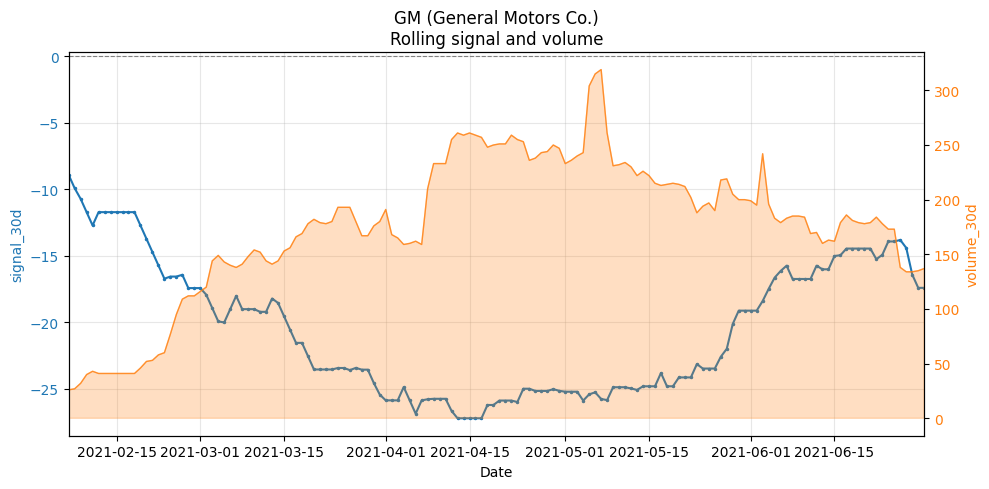

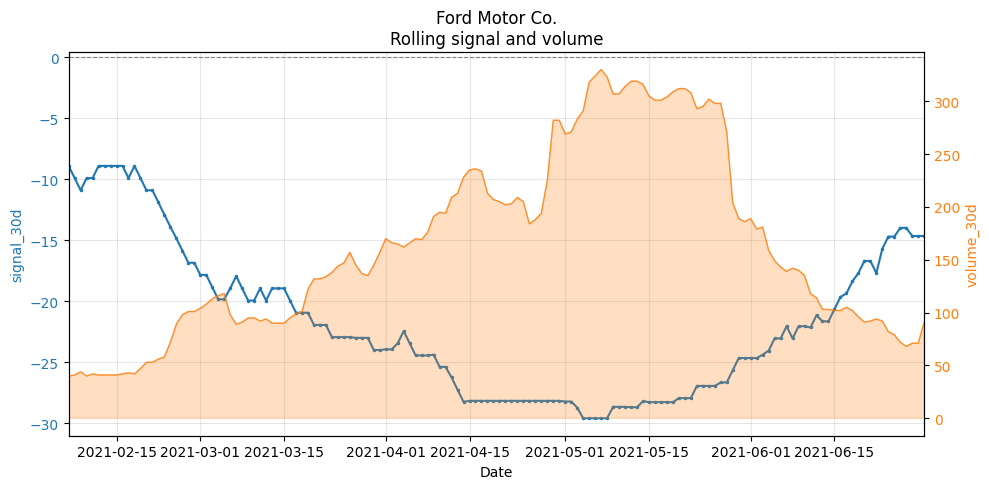

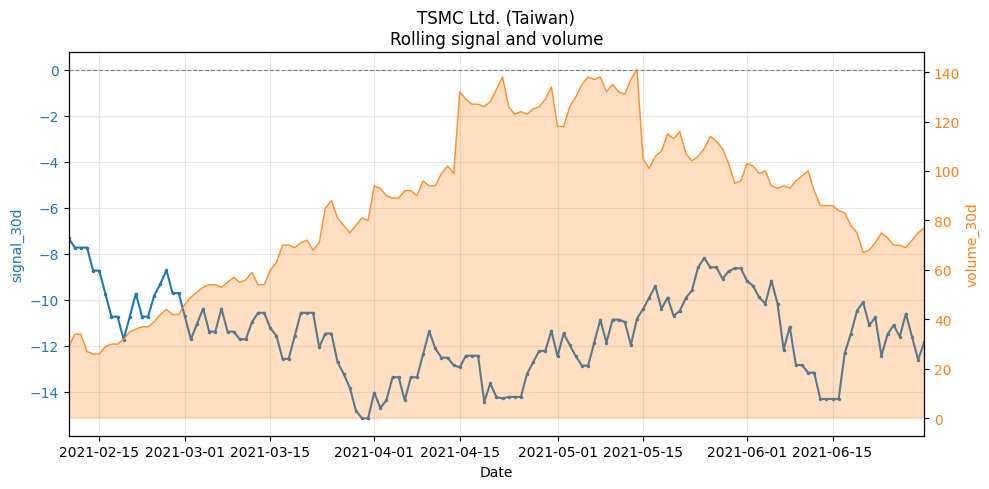

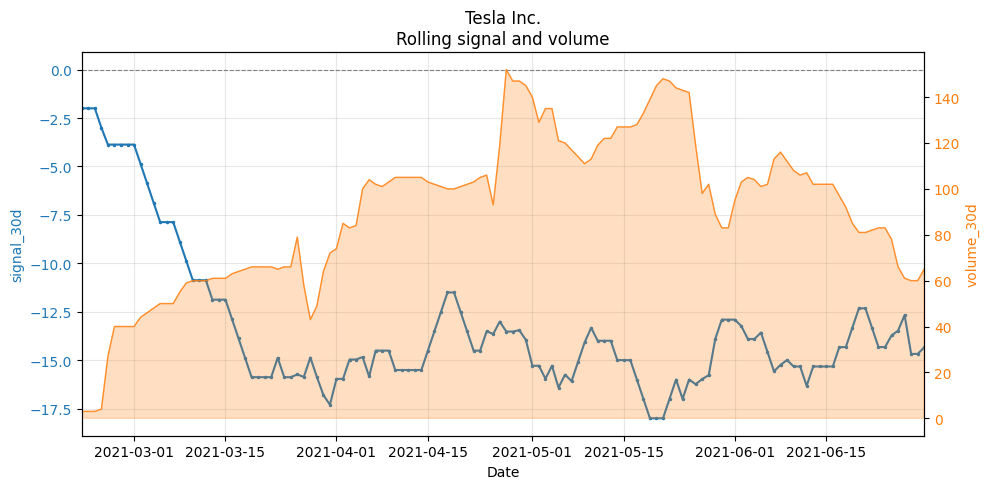

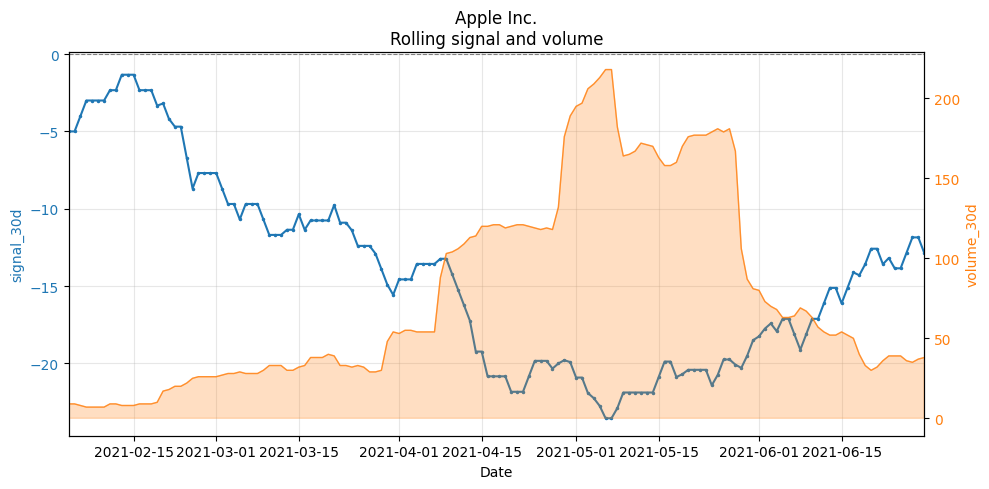

In [38]:
# Plot rolling signal for top 5 companies by volume
plot_top_entities_rolling_signal(
    df_rolling_signal,
    entity_col="entity_name",
    date_col="date",
    signal_col="signal_30d",  # with the relative padding from window
    top_n=5,
)



In [42]:
# Save DF with rp_entity_id included
entity_id_map = (
    df_with_labels[["entity_name", "entity_id"]]
    .dropna(subset=["entity_name", "entity_id"])
    .drop_duplicates(subset=["entity_name"])
    .set_index("entity_name")["entity_id"]
)

df_rolling_signal_export = df_rolling_signal.copy()
if "rp_entity_id" not in df_rolling_signal_export.columns:
    df_rolling_signal_export["rp_entity_id"] = df_rolling_signal_export["entity_name"].map(entity_id_map)

# Put rp_entity_id near the entity name for easier downstream use
desired_order = ["entity_name", "rp_entity_id"] + [
    col for col in df_rolling_signal_export.columns if col not in {"entity_name", "rp_entity_id"}
]
df_rolling_signal_export = df_rolling_signal_export[desired_order]

df_rolling_signal_export.to_csv("df_rolling_signal.csv", index=False)


  ## Summary







  This workflow showed a complete pipeline: theme decomposition for higher recall, Smart Batching for efficient large-scale search, entity resolution via Knowledge Graph API, LLM validation for theme relevance and impact assessment, and rolling signal construction for trend analysis. The main output is a **signal table** (e.g. `df_rolling_signal`): one row per (entity, date) with `signal_7d` and `signal_30d`, ready for backtesting or screening.



